In [9]:
import numpy as np
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import logging
from typing import Union

from skimage import io
from skimage.measure import regionprops
from skimage import filters, morphology, measure, exposure
from skimage.segmentation import find_boundaries

import matplotlib.pyplot as plt

In [10]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import joblib
import cv2
import numpy as np
from skimage.feature import peak_local_max
# 0: channel 640, 1: channel 488, 2 Bright Field, 3: folder name
data = joblib.load("../1-pipeline/processed_data/aliveData.joblib")

In [11]:
def segment_bright_bacteria(
    image: np.ndarray,
    min_area: int = 3,
    max_area: int = 200,
    sigma_bg: float = 10,
    threshold_scale: float = 0.8
) -> tuple[np.ndarray, np.ndarray]:
    """
    Segment bright fluorescent bacteria using classical image processing.
    """

    image = image.astype(np.float32)

    # Background subtraction
    background = filters.gaussian(image, sigma=sigma_bg)
    corrected = image - background
    corrected[corrected < 0] = 0

    # Normalize to 0-1
    corrected = exposure.rescale_intensity(
        corrected,
        in_range="image",
        out_range=(0, 1)
    )

    # Threshold
    otsu_threshold = filters.threshold_otsu(corrected)
    threshold = otsu_threshold * threshold_scale
    binary = corrected > threshold

    # Clean objects
    binary = morphology.remove_small_objects(binary, min_size=min_area)
    binary = morphology.remove_small_holes(binary, area_threshold=2)

    # Lightly close small gaps
    binary = morphology.binary_closing(binary, morphology.disk(1))

    # Label objects
    labelled = measure.label(binary)

    # Filter by object area
    filtered_mask = np.zeros_like(labelled, dtype=np.uint16)
    new_label = 1

    for region in measure.regionprops(labelled):
        if min_area <= region.area <= max_area:
            filtered_mask[labelled == region.label] = new_label
            new_label += 1

    return filtered_mask, corrected

In [12]:
def filter_mask(mask: np.ndarray, options: dict = {}) -> np.ndarray:
    """
    Filter segmentation mask based on area, length, and width.
    """

    min_area = options.get("min_area", None)
    max_area = options.get("max_area", None)

    min_length = options.get("min_length", None)
    max_length = options.get("max_length", None)

    min_width = options.get("min_width", None)
    max_width = options.get("max_width", None)

    label_mask = np.copy(mask)

    if label_mask.ndim == 2:
        regions = regionprops(label_mask)

        filtered_mask = np.zeros_like(mask)

        for region in regions:
            area = region.area
            length = region.axis_major_length
            width = region.axis_minor_length

            if (
                (min_area is None or area >= min_area)
                and (max_area is None or area <= max_area)
                and (min_length is None or length >= min_length)
                and (max_length is None or length <= max_length)
                and (min_width is None or width >= min_width)
                and (max_width is None or width <= max_width)
            ):
                filtered_mask[label_mask == region.label] = region.label

    elif label_mask.ndim == 3:
        filtered_mask = np.zeros_like(mask)

        for i, current_mask in enumerate(label_mask):
            current_filtered_mask = filter_mask(current_mask, options=options)
            filtered_mask[i] = current_filtered_mask

    else:
        raise ValueError("Mask must be 2D or 3D.")

    return filtered_mask

In [13]:
def preview_results(original, corrected, masks):
    """
    Preview original image, corrected image, mask, and overlay.
    """

    boundaries = find_boundaries(masks, mode="outer")

    mask_display = exposure.rescale_intensity(
        masks.astype(np.float32),
        in_range="image",
        out_range=(0, 1)
    )

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(corrected, cmap="gray")
    plt.title("Corrected image")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(mask_display, cmap="gray")
    plt.title("Segmentation mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(original, cmap="gray")
    plt.contour(boundaries, colors="red", linewidths=0.5)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [14]:
def save_overlay(image, masks, output_path):
    """
    Save an overlay image showing segmentation boundaries on the original image.
    """

    boundaries = find_boundaries(masks, mode="outer")

    plt.figure(figsize=(8, 8))
    plt.imshow(image, cmap="gray")
    plt.contour(boundaries, colors="red", linewidths=0.5)
    plt.axis("off")
    plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

In [15]:
image_640 = data[43][0]
image_488 = data[43][1]

print(f"Loaded image shape: {image_640.shape}")
print(f"Image dtype: {image_640.dtype}")
print(f"Image_640 min/max: {image_640.min()} / {image_640.max()}")
print(f"image_488 min/max: {image_488.min()} / {image_488.max()}")

Loaded image shape: (684, 428)
Image dtype: uint16
Image_640 min/max: 3145 / 65535
image_488 min/max: 1592 / 65535


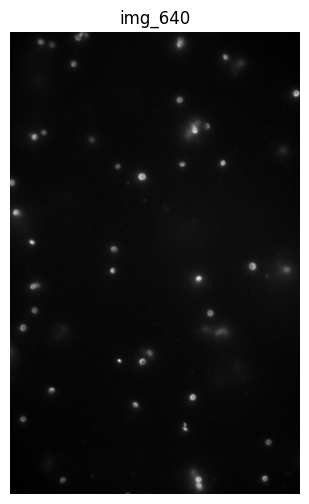

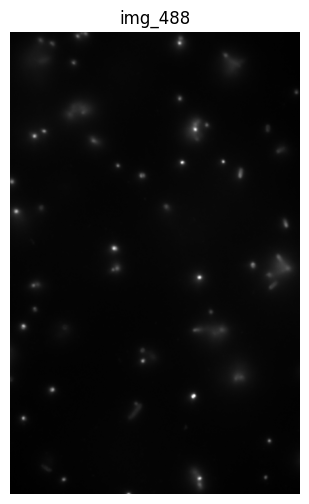

In [16]:
img_640 = image_640.copy()
img_488 = image_488.copy()
image = [img_640, img_488]
img = ['img_640', 'img_488']

for i in range(len(img)):
    plt.figure(figsize=(6, 6))
    plt.imshow(image[i], cmap="gray")
    plt.title(img[i])
    plt.axis("off")
    plt.show()

In [17]:
masks = []
corrected = []

for i in range(len(img)):
    maski, correctedi = segment_bright_bacteria(
        image[i],
        min_area=3,
        max_area=200,
        sigma_bg=10,
        threshold_scale=0.6
    )
    masks.append(maski)
    corrected.append(correctedi)

    print(f"Image name: {img[i]}")
    print(f"Masks shape: {maski.shape}")
    print("Unique mask values:", np.unique(maski))
    print("Number of objects:", len(np.unique(maski)) - 1)
    print("\n")

Image name: img_640
Masks shape: (684, 428)
Unique mask values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
Number of objects: 47


Image name: img_488
Masks shape: (684, 428)
Unique mask values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55]
Number of objects: 55




C:\Users\HP\AppData\Local\Temp\ipykernel_35676\2438560156.py:32: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = morphology.remove_small_objects(binary, min_size=min_area)
C:\Users\HP\AppData\Local\Temp\ipykernel_35676\2438560156.py:33: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = morphology.

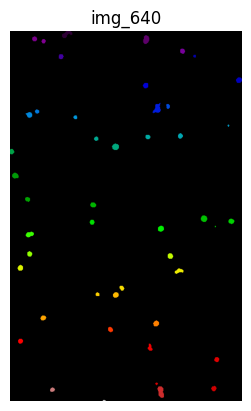

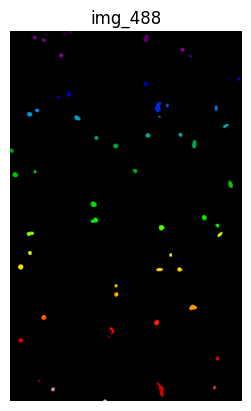

In [18]:
for i in range(len(img)):
    plt.imshow(masks[i], cmap="nipy_spectral")
    plt.title(img[i])
    plt.axis("off")
    plt.show()

In [19]:
import pandas as pd
from skimage.measure import regionprops


def measurements(mask, img):
    measurements = []

    regions = regionprops(mask, intensity_image=img)

    for region in regions:
        label_id = region.label

        area = region.area

        y, x = region.centroid

        y_min, x_min, y_max, x_max = region.bbox

        major_length = region.axis_major_length
        minor_length = region.axis_minor_length
        eccentricity = region.eccentricity
        solidity = region.solidity

        mean_intensity = region.intensity_mean
        max_intensity = region.intensity_max

        measurements.append({
            "label": label_id,
            "area": area,
            "x": x,
            "y": y,
            "x_min": x_min,
            "y_min": y_min,
            "x_max": x_max,
            "y_max": y_max,
            "major_length": major_length,
            "minor_length": minor_length,
            "eccentricity": eccentricity,
            "solidity": solidity,
            "mean_intensity": mean_intensity,
            "max_intensity": max_intensity,
        })

    df_measure = pd.DataFrame(measurements)

    df_measure.head()

    # print(df_measure)

    return df_measure

In [20]:
m = []
for i in range(len(img)):
    print(f"Image name: {img[i]}")
    measure = measurements(masks[i], image[i])
    m.append(measure)
    print(m)
    print("\n")

Image name: img_640
[    label   area           x           y  x_min  y_min  x_max  y_max  \
0       1  141.0  104.212766    5.439716     96      0    115     13   
1       2  141.0  250.744681   15.482270    245      8    257     24   
2       3   66.0   44.939394   14.151515     41     10     50     19   
3       4   49.0   61.571429   18.469388     58     15     66     23   
4       5   69.0  317.797101   36.768116    314     32    323     42   
5       6   67.0   93.686567   46.910448     90     43     99     52   
6       7   23.0  340.173913   46.000000    338     44    343     49   
7       8   92.0  422.054348   90.413043    417     85    428     96   
8       9   81.0  249.938272  100.345679    245     96    255    106   
9      10  171.0  271.198830  143.070175    263    133    278    152   
10     11   50.0  291.080000  138.840000    288    135    295    144   
11     12   48.0   49.541667  148.395833     46    145     54    153   
12     13   90.0   35.166667  154.566667   

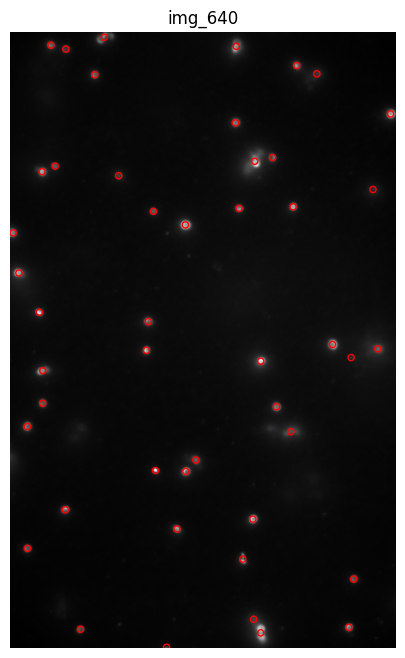

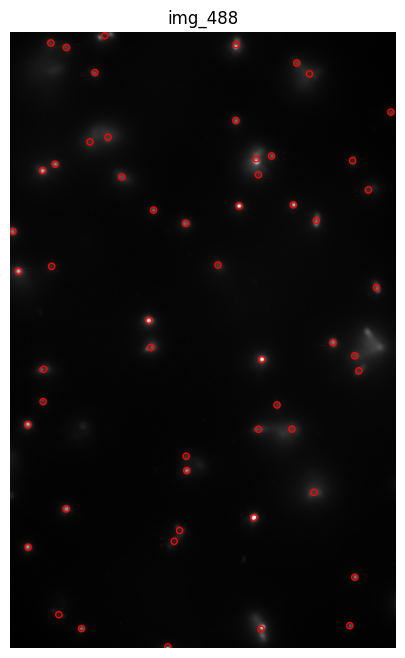

In [21]:
import matplotlib.pyplot as plt

for i in range(len(img)):

    plt.figure(figsize=(8, 8))
    plt.imshow(image[i], cmap="gray")

    plt.scatter(
        m[i]["x"],
        m[i]["y"],
        s=20,
        facecolors="none",
        edgecolors="red",
        linewidths=1
    )
    plt.title(img[i])
    plt.axis("off")
    plt.show()

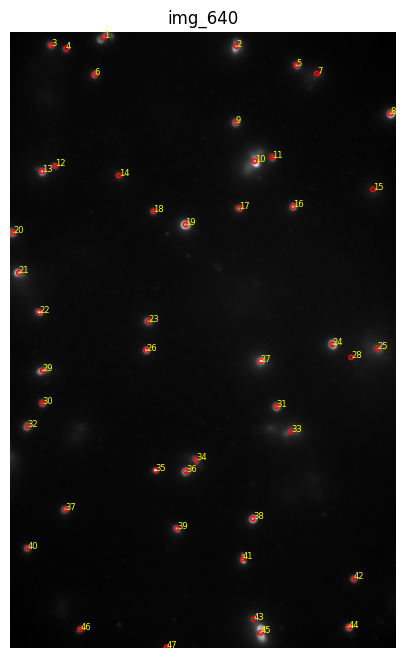

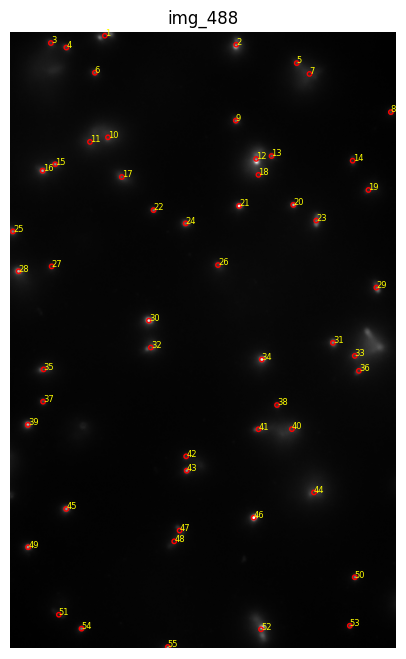

In [22]:
for i in range(len(img)):

    plt.figure(figsize=(8, 8))
    plt.imshow(image[i], cmap="gray")

    plt.scatter(
        m[i]["x"],
        m[i]["y"],
        s=10,
        facecolors="none",
        edgecolors="red"
    )

    for _, row in m[i].iterrows():
        plt.text(
            row["x"],
            row["y"],
            str(int(row["label"])),
            color="yellow",
            fontsize=6
        )
    plt.title(img[i])
    plt.axis("off")
    plt.show()

Image name: img_640


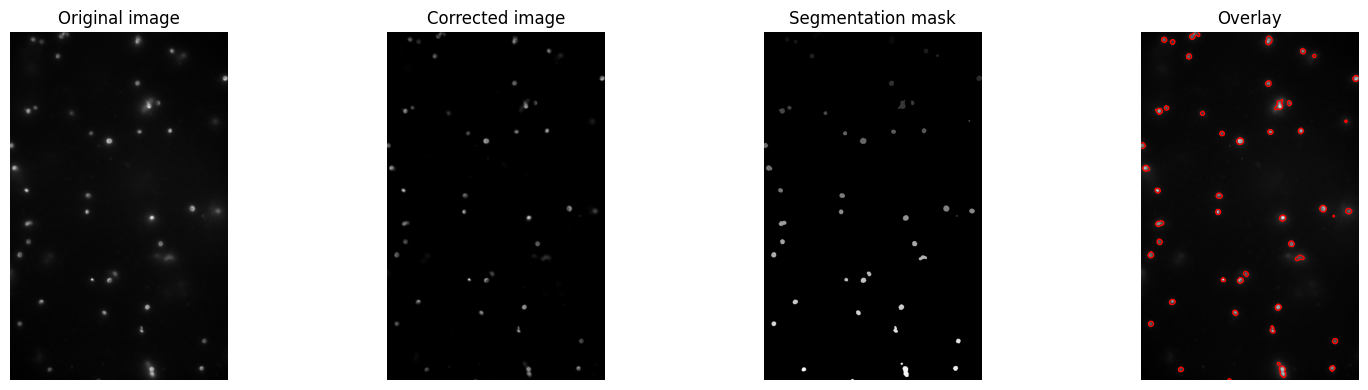

Image name: img_488


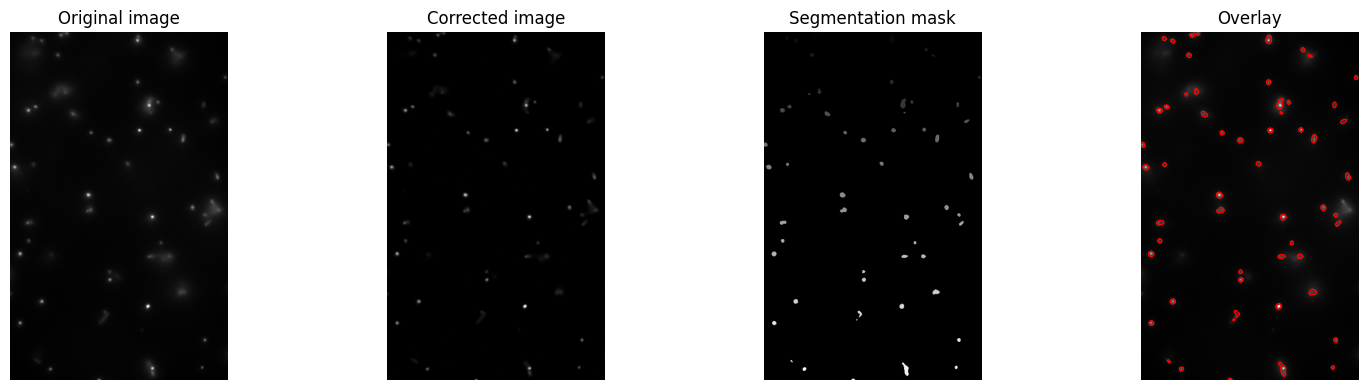

In [23]:
for i in range(len(img)):
    print(f"Image name: {img[i]}")
    preview_results(image[i], corrected[i],  masks[i])

# HERE

In [24]:
from scipy.spatial import cKDTree
import numpy as np
import pandas as pd


def match_two_channels_greedy(
    df_a,
    df_b,
    tolerance=3,
    area_ratio_warning=3.0,
    channel_a_name="640",
    channel_b_name="488",
    class_shared="shared",
    class_a_only=None,
    class_b_only=None,
):
    """
    Match two-channel bacteria measurements by centroid distance.

    Returns:
        shared: matched object table
        a_only: objects only in channel A
        b_only: objects only in channel B
        df_a_labeled: original df_a with matching labels
        df_b_labeled: original df_b with matching labels
        combined: one-row-per-candidate summary table
    """

    if class_a_only is None:
        class_a_only = f"{channel_a_name}_only"

    if class_b_only is None:
        class_b_only = f"{channel_b_name}_only"

    df_a = df_a.copy().reset_index(drop=True)
    df_b = df_b.copy().reset_index(drop=True)

    required_cols = {"label", "x", "y", "area"}
    missing_a = required_cols - set(df_a.columns)
    missing_b = required_cols - set(df_b.columns)

    if missing_a:
        raise ValueError(f"df_a is missing columns: {missing_a}")

    if missing_b:
        raise ValueError(f"df_b is missing columns: {missing_b}")

    pts_a = df_a[["x", "y"]].to_numpy()
    pts_b = df_b[["x", "y"]].to_numpy()

    tree_b = cKDTree(pts_b)
    nearby = tree_b.query_ball_point(pts_a, r=tolerance)

    pairs = []

    for i_a, b_candidates in enumerate(nearby):
        for i_b in b_candidates:
            d = np.linalg.norm(pts_a[i_a] - pts_b[i_b])
            pairs.append((d, i_a, i_b))

    pairs = sorted(pairs, key=lambda x: x[0])

    used_a = set()
    used_b = set()
    matches = []

    for d, i_a, i_b in pairs:
        if i_a in used_a or i_b in used_b:
            continue

        row_a = df_a.iloc[i_a]
        row_b = df_b.iloc[i_b]

        area_a = row_a["area"]
        area_b = row_b["area"]
        area_ratio = max(area_a, area_b) / (min(area_a, area_b) + 1e-8)

        matches.append({
            f"{channel_a_name}_index": i_a,
            f"{channel_b_name}_index": i_b,
            f"{channel_a_name}_label": row_a["label"],
            f"{channel_b_name}_label": row_b["label"],

            "x": (row_a["x"] + row_b["x"]) / 2,
            "y": (row_a["y"] + row_b["y"]) / 2,

            f"x_{channel_a_name}": row_a["x"],
            f"y_{channel_a_name}": row_a["y"],
            f"x_{channel_b_name}": row_b["x"],
            f"y_{channel_b_name}": row_b["y"],

            "distance": d,

            f"area_{channel_a_name}": area_a,
            f"area_{channel_b_name}": area_b,
            "area_ratio": area_ratio,
            "area_warning": area_ratio > area_ratio_warning,

            f"in_{channel_a_name}": True,
            f"in_{channel_b_name}": True,
            "category": class_shared,
        })

        used_a.add(i_a)
        used_b.add(i_b)

    shared = pd.DataFrame(matches)

    a_only = df_a.loc[
        [i for i in range(len(df_a)) if i not in used_a]
    ].copy()

    b_only = df_b.loc[
        [i for i in range(len(df_b)) if i not in used_b]
    ].copy()

    a_only[f"in_{channel_a_name}"] = True
    a_only[f"in_{channel_b_name}"] = False
    a_only["category"] = class_a_only

    b_only[f"in_{channel_a_name}"] = False
    b_only[f"in_{channel_b_name}"] = True
    b_only["category"] = class_b_only

    # ------------------------------------------------------------
    # 1. Write labels back into the two original dataframes
    # ------------------------------------------------------------

    df_a_labeled = df_a.copy()
    df_b_labeled = df_b.copy()

    for df_labeled in [df_a_labeled, df_b_labeled]:
        df_labeled["match_category"] = "unmatched"
        df_labeled["matched_label"] = np.nan
        df_labeled["match_distance"] = np.nan
        df_labeled["area_ratio"] = np.nan
        df_labeled["area_warning"] = False

    if len(shared) > 0:
        for _, row in shared.iterrows():
            a_idx = int(row[f"{channel_a_name}_index"])
            b_idx = int(row[f"{channel_b_name}_index"])

            df_a_labeled.loc[a_idx, "match_category"] = class_shared
            df_a_labeled.loc[a_idx, "matched_label"] = row[f"{channel_b_name}_label"]
            df_a_labeled.loc[a_idx, "match_distance"] = row["distance"]
            df_a_labeled.loc[a_idx, "area_ratio"] = row["area_ratio"]
            df_a_labeled.loc[a_idx, "area_warning"] = row["area_warning"]

            df_b_labeled.loc[b_idx, "match_category"] = class_shared
            df_b_labeled.loc[b_idx, "matched_label"] = row[f"{channel_a_name}_label"]
            df_b_labeled.loc[b_idx, "match_distance"] = row["distance"]
            df_b_labeled.loc[b_idx, "area_ratio"] = row["area_ratio"]
            df_b_labeled.loc[b_idx, "area_warning"] = row["area_warning"]

    df_a_labeled.loc[list(a_only.index), "match_category"] = class_a_only
    df_b_labeled.loc[list(b_only.index), "match_category"] = class_b_only

    # ------------------------------------------------------------
    # 2. Build one combined summary table
    # ------------------------------------------------------------

    combined_rows = []

    if len(shared) > 0:
        for _, row in shared.iterrows():
            combined_rows.append({
                "object_class": class_shared,
                "x": row["x"],
                "y": row["y"],

                f"{channel_a_name}_label": row[f"{channel_a_name}_label"],
                f"{channel_b_name}_label": row[f"{channel_b_name}_label"],

                f"in_{channel_a_name}": True,
                f"in_{channel_b_name}": True,

                "distance": row["distance"],
                "area_ratio": row["area_ratio"],
                "area_warning": row["area_warning"],

                f"area_{channel_a_name}": row[f"area_{channel_a_name}"],
                f"area_{channel_b_name}": row[f"area_{channel_b_name}"],
            })

    for _, row in a_only.iterrows():
        combined_rows.append({
            "object_class": class_a_only,
            "x": row["x"],
            "y": row["y"],

            f"{channel_a_name}_label": row["label"],
            f"{channel_b_name}_label": np.nan,

            f"in_{channel_a_name}": True,
            f"in_{channel_b_name}": False,

            "distance": np.nan,
            "area_ratio": np.nan,
            "area_warning": False,

            f"area_{channel_a_name}": row["area"],
            f"area_{channel_b_name}": np.nan,
        })

    for _, row in b_only.iterrows():
        combined_rows.append({
            "object_class": class_b_only,
            "x": row["x"],
            "y": row["y"],

            f"{channel_a_name}_label": np.nan,
            f"{channel_b_name}_label": row["label"],

            f"in_{channel_a_name}": False,
            f"in_{channel_b_name}": True,

            "distance": np.nan,
            "area_ratio": np.nan,
            "area_warning": False,

            f"area_{channel_a_name}": np.nan,
            f"area_{channel_b_name}": row["area"],
        })

    combined = pd.DataFrame(combined_rows)

    return shared, a_only, b_only, df_a_labeled, df_b_labeled, combined

In [25]:
shared, only_640, only_488, df_640_labeled, df_488_labeled, combined = match_two_channels_greedy(
    df_a=m[0],
    df_b=m[1],
    tolerance=3,
    area_ratio_warning=3.0,
    channel_a_name="640",
    channel_b_name="488"
)

In [26]:
df_640_labeled.to_csv("df_640_labeled.csv", index=False)
df_488_labeled.to_csv("df_488_labeled.csv", index=False)
combined.to_csv("combined_640_488_classification.csv", index=False)

Image name: img_640


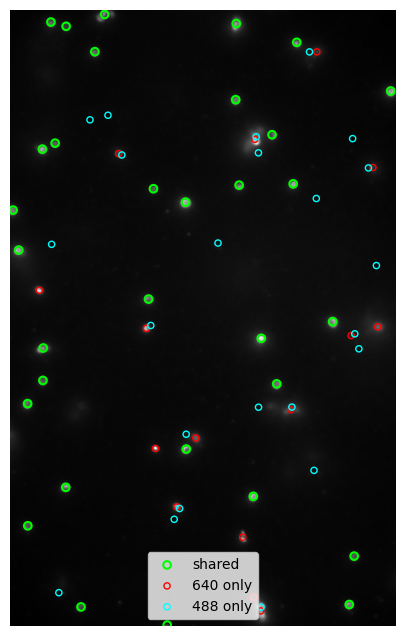


Image name: img_488


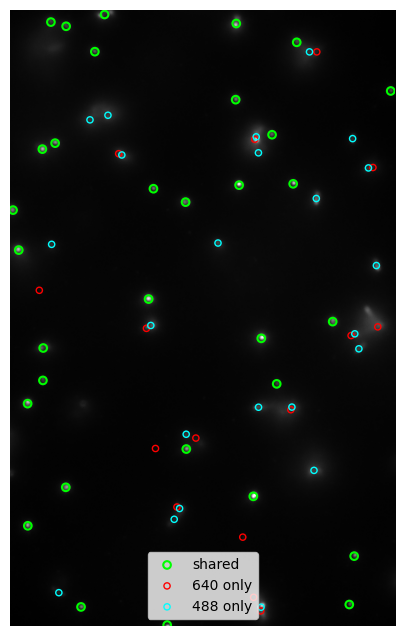

In [28]:
import matplotlib.pyplot as plt


def show_label(image,shared,A_only,B_only):
    plt.figure(figsize=(8, 8))
    plt.imshow(image, cmap="gray")
    plt.scatter(
        shared["x"],
        shared["y"],
        s=30,
        facecolors="none",
        edgecolors="lime",
        linewidths=1.5,
        label="shared"
    )

    plt.scatter(
        A_only["x"],
        A_only["y"],
        s=20,
        facecolors="none",
        edgecolors="red",
        linewidths=1,
        label="640 only"
    )

    plt.scatter(
        B_only["x"],
        B_only["y"],
        s=20,
        facecolors="none",
        edgecolors="cyan",
        linewidths=1,
        label="488 only"
    )

    plt.legend()
    plt.axis("off")
    plt.show()

print(f"Image name: img_640")
show_label(image[0],shared,only_640, only_488)
print(f"\nImage name: img_488")
show_label(image[1],shared,only_640, only_488)